## Objectives:
1. Load pretrained BERT model
2. Perform hyperparameter tuning
3. Fully finetune BERT model
4. Evaluate model performance on test data
5. Perform error analysis & adversarial testing

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

Load the data

In [ ]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df.head())

(34944, 2) (7464, 2) (7484, 2)
      label                                             review
0  positive  best cheap GPS: The Garmin Etrex, at under $10...
1  positive  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2  negative  So good we now buy Brother: Installing one of ...
3  positive  Powerful: Austin brings to life a part of the ...
4  positive  Tao terrific: This read is very informational ...


In [ ]:
# Convert string labels to binary labels
label_to_id_map = {"negative": 0, "positive": 1}
id_to_label_map = {0: "negative", 1: "positive"}
train_df["label"] = train_df["label"].map(label_to_id_map)
val_df["label"] = val_df["label"].map(label_to_id_map)
test_df["label"] = test_df["label"].map(label_to_id_map)
print(train_df.head())

   label                                             review
0      1  best cheap GPS: The Garmin Etrex, at under $10...
1      1  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2      0  So good we now buy Brother: Installing one of ...
3      1  Powerful: Austin brings to life a part of the ...
4      1  Tao terrific: This read is very informational ...


Load pretrained model and tokenizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenize text

In [ ]:
def tokenize_function(text):
    return tokenizer(text["review"], padding="max_length", truncation=True)

# Convert pandas DataFrames to Dataset objects
train_df = Dataset.from_pandas(train_df)
val_df = Dataset.from_pandas(val_df)
test_df = Dataset.from_pandas(test_df)

tokenized_train_df = train_df.map(tokenize_function, batched=True)
tokenized_val_df = val_df.map(tokenize_function, batched=True)
tokenized_test_df = test_df.map(tokenize_function, batched=True)

Map:   0%|          | 0/34944 [00:00<?, ? examples/s]

Map:   0%|          | 0/7464 [00:00<?, ? examples/s]

Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

Define metrics

In [ ]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

Hyperparameter tuning

In [ ]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 17.9 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):
    # Define the hyperparameter search space
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    weight_decay = trial.suggest_float("weight_decay", 0.001, 0.01, log=True)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir=model_name,
        eval_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=1,
        weight_decay=weight_decay,
        fp16=True,
        save_strategy="epoch",
        disable_tqdm=False,
        report_to="none"
    )

    # Initialize Trainer and train model
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        train_dataset=tokenized_train_df,
        eval_dataset=tokenized_val_df
    )
    trainer.train()

    # Evaluate the model and return validation accuracy
    eval_results = trainer.evaluate()
    return eval_results["eval_accuracy"]

# Will be trying 5 different sets of hyperparameters
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best hyperparameters:", study.best_params)

[I 2025-11-11 02:25:05,744] A new study created in memory with name: no-name-e9a97de1-3eaf-4237-9243-b045b0535a3e


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.156500,0.148115,0.948955,0.948959


[I 2025-11-11 02:41:55,079] Trial 0 finished with value: 0.9489549839228296 and parameters: {'learning_rate': 3.498264836078287e-05, 'batch_size': 16, 'weight_decay': 0.0061296520949725925}. Best is trial 0 with value: 0.9489549839228296.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.142800,0.207403,0.951367,0.951369


[I 2025-11-11 03:00:02,974] Trial 1 finished with value: 0.9513665594855305 and parameters: {'learning_rate': 1.6575693064412677e-05, 'batch_size': 8, 'weight_decay': 0.0013367336197616317}. Best is trial 1 with value: 0.9513665594855305.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.002800,0.398047,0.948955,0.948958


[I 2025-11-11 07:42:25,770] Trial 18 finished with value: 0.9489549839228296 and parameters: {'learning_rate': 1.8323885655076946e-05, 'batch_size': 32, 'weight_decay': 0.007103820245821639}. Best is trial 2 with value: 0.9516345123258306.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.019600,0.396166,0.949357,0.949351


[I 2025-11-11 08:00:29,614] Trial 19 finished with value: 0.9493569131832797 and parameters: {'learning_rate': 2.7590063469680627e-05, 'batch_size': 8, 'weight_decay': 0.0013390629525323748}. Best is trial 2 with value: 0.9516345123258306.


Best hyperparameters: {'learning_rate': 2.3089145053694122e-05, 'batch_size': 32, 'weight_decay': 0.007411740111445008}


Train the model using the best hyperparameters

In [ ]:
model_name = "full-finetuned-bert-amazon-reviews"

# Define hyperaparamters
best_learning_rate = study.best_params["learning_rate"]
best_batch_size = study.best_params["batch_size"]
best_weight_decay = study.best_params["weight_decay"]
#best_learning_rate = 2.3089e-5
#best_batch_size = 32
#best_weight_decay = 0.0074117

# Define training arguments
training_args = TrainingArguments(
    output_dir=model_name,
    eval_strategy="epoch",
    learning_rate=best_learning_rate,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    num_train_epochs=1,
    weight_decay=best_weight_decay,
    fp16=True,
    save_strategy="epoch",
    disable_tqdm=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_train_df,
    eval_dataset=tokenized_val_df
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.007500,0.369159,0.949491,0.949492


TrainOutput(global_step=1092, training_loss=0.018107814448220388, metrics={'train_runtime': 947.5825, 'train_samples_per_second': 36.877, 'train_steps_per_second': 1.152, 'total_flos': 9194152718499840.0, 'train_loss': 0.018107814448220388, 'epoch': 1.0})

Evaluate the model

In [ ]:
# Evaluate on test data
preds_outputs = trainer.predict(tokenized_test_df)
preds_outputs.metrics

{'test_loss': 0.37393736839294434,
 'test_accuracy': 0.9498931052912881,
 'test_f1': 0.9498882494196265,
 'test_runtime': 57.4054,
 'test_samples_per_second': 130.371,
 'test_steps_per_second': 4.076}

              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      3670
    positive       0.95      0.95      0.95      3814

    accuracy                           0.95      7484
   macro avg       0.95      0.95      0.95      7484
weighted avg       0.95      0.95      0.95      7484



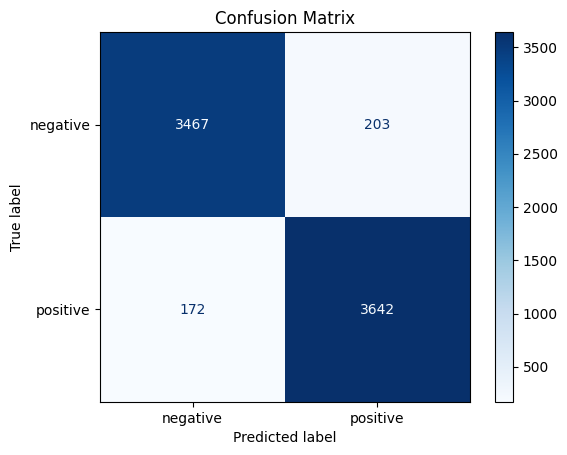

In [ ]:
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = [label for label in tokenized_test_df["label"]]
print(classification_report(y_true, y_preds, zero_division=0, target_names=id_to_label_map.values()))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id_to_label_map.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Error analysis

In [ ]:
# Identify misclassified examples
misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_true, y_preds)) if true != pred]
misclassified_reviews = [test_df["review"][i] for i in misclassified_indices]
misclassified_true_labels = [id_to_label_map[y_true[i]] for i in misclassified_indices]
misclassified_predicted_labels = [id_to_label_map[y_preds[i]] for i in misclassified_indices]

# Display a few misclassified examples
print(f"Number of misclassified examples: {len(misclassified_indices)}")
print("\nSample misclassified examples:")
for i in range(min(5, len(misclassified_indices))):
    print(f"Review: {misclassified_reviews[i]}")
    print(f"True label: {misclassified_true_labels[i]}")
    print(f"Predicted label: {misclassified_predicted_labels[i]}")
    print("-" * 50)

Number of misclassified examples: 375

Sample misclassified examples:
Review: ELI THE KING: I thought that this book was a good book. It was very interesting.I also thought that it had to much swearing in it.sincerely, The King Eli
True label: negative
Predicted label: positive
--------------------------------------------------
Review: HD vieo is very good but the music is cheesy.: I bought this to have the HD fireplace scenes along with Christmas music playing in the background when we had guests over for the holidays. The HD video was very nice but I was also expecting a quality arrangement of Christmas music to go with it. What we got was someone playing Christmas tunes on an electronic keyboard. It sounded cheap and cheesy. Fortunately we could turn off the music and just enjoy the fire. If you do not care about the music this is nice at a good price.
True label: negative
Predicted label: positive
--------------------------------------------------
Review: Kindle version reformatted

Adversarial testing

In [ ]:
# Test with adversarial examples, such as oxymorons, spelling errors, conflicting sentiments, sarcasm
adversarial_inputs = ["This movie was surprisingly not bad!",         # true label: positive
                      "This book is ecellent",                        # true label: positive
                      "This is good, but it is too expensive.",       # true label: negative
                      "The service was great... (not really)"]        # true label: negative

for text in adversarial_inputs:
    tokenized_inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    tokenized_inputs = {name: tensor.to(device) for name, tensor in tokenized_inputs.items()}

    outputs = model(**tokenized_inputs)
    predictions = torch.argmax(outputs.logits, axis=1)
    print(f"Adversarial prediction for '{text}': {id_to_label_map[predictions.item()]}")

Adversarial prediction for 'This movie was surprisingly not bad!': positive
Adversarial prediction for 'This book is ecellent': positive
Adversarial prediction for 'This is good, but it is too expensive.': negative
Adversarial prediction for 'The service was great... (not really)': positive


Save the model

In [ ]:
!pip install huggingface_hub --quiet

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# This will create a public repository under your username.
REPO_ID = "full-finetuned-bert-for-Amazon-sentiment-analysis"

# Push the model and tokenizer to the Hub
model.push_to_hub(REPO_ID, commit_message="Full-finetuned bert model")
tokenizer.push_to_hub(REPO_ID)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...08_s73i/model.safetensors:   0%|          | 14.2kB /  438MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/cxl1020/full-finetuned-bert-for-Amazon-sentiment-analysis/commit/1d5378722452a749ec3cf67a5b9b771aaa3c65ca', commit_message='Upload tokenizer', commit_description='', oid='1d5378722452a749ec3cf67a5b9b771aaa3c65ca', pr_url=None, repo_url=RepoUrl('https://huggingface.co/cxl1020/full-finetuned-bert-for-Amazon-sentiment-analysis', endpoint='https://huggingface.co', repo_type='model', repo_id='cxl1020/full-finetuned-bert-for-Amazon-sentiment-analysis'), pr_revision=None, pr_num=None)